<center><img src="https://i.imgur.com/zRrFdsf.png" width="700"></center>





<a target="_blank" href="https://colab.research.google.com/github/CienciaDeDatosEspacial/spatial_autoCorr/blob/main/index.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Neighboorhood and Spatial Correlation.



## Getting ready


### Libraries needed

Let's verify:

In [51]:
!pip show pysal pandas geopandas

Name: pysal
Version: 25.7
Summary: Meta Package for PySAL - A library of spatial analysis functions
Home-page: 
Author: 
Author-email: Serge Rey <sjsrey@gmail.com>, Levi Wolf <levi.john.wolf@gmail.com>
License: BSD 3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: access, beautifulsoup4, esda, geopandas, giddy, inequality, libpysal, mapclassify, mgwr, momepy, numpy, packaging, pandas, platformdirs, pointpats, requests, scikit-learn, scipy, segregation, shapely, spaghetti, spglm, spint, splot, spopt, spreg, tobler
Required-by: 
---
Name: pandas
Version: 2.2.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution 

In [52]:
## needed in Colab
!pip install pysal

### Data to use

Let me get two maps:

1. Here we have the USA map, at **state level**,  directly from census.gov, which has a good quality.

In [53]:
import geopandas as gpd

url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip"
us_states = gpd.read_file(url)

# checking data type,  crs, and confirming crs is projected
us_states.info(),us_states.crs.to_epsg(),us_states.crs.is_projected

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   56 non-null     object  
 1   STATENS   56 non-null     object  
 2   GEOIDFQ   56 non-null     object  
 3   GEOID     56 non-null     object  
 4   STUSPS    56 non-null     object  
 5   NAME      56 non-null     object  
 6   LSAD      56 non-null     object  
 7   ALAND     56 non-null     int64   
 8   AWATER    56 non-null     int64   
 9   geometry  56 non-null     geometry
dtypes: geometry(1), int64(2), object(7)
memory usage: 4.5+ KB


(None, 4269, False)

Notice this map has basic information per state:

In [54]:
us_states.head()

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198587197,726463919,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341525171,3387709166,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185049346,4582326383,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."


Also, notice the current **unprojected** crs will plot this:

<Axes: >

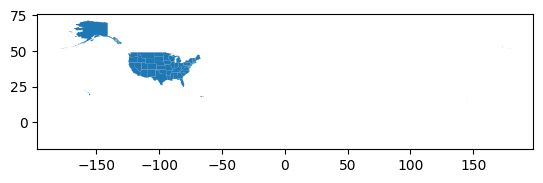

In [55]:
us_states.plot()

Let's reproject the crs:

<Axes: >

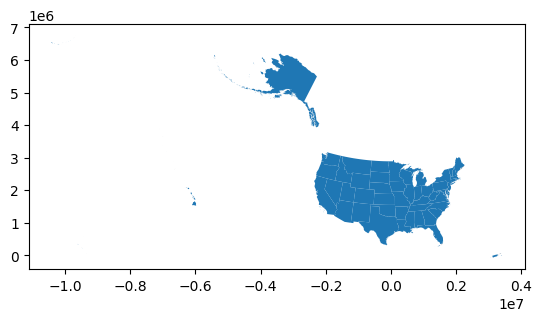

In [56]:
us_states=us_states.to_crs(5070)
us_states.plot()

Let's use the state name **as index**, that would help an easier identification of the places when we see most outputs (otherwise we will see just numerical indexes) :

In [57]:
us_states.set_index('NAME', inplace=True)
us_states.head()

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,LSAD,ALAND,AWATER,geometry
NAME,,,,,,,,,
New Mexico,35,00897535,0400000US35,35,NM,00,314198587197,726463919,"POLYGON ((-1231344.076 1018550.43, -1231015.83..."
South Dakota,46,01785534,0400000US46,46,SD,00,196341525171,3387709166,"POLYGON ((-633765.574 2472338.835, -633207.122..."
California,06,01779778,0400000US06,06,CA,00,403673296401,20291770234,"MULTIPOLYGON (((-2066923.367 1403703.122, -206..."
Kentucky,21,01779786,0400000US21,21,KY,00,102266598312,2384223544,"MULTIPOLYGON (((584560.04 1518183.089, 585066...."
Alabama,01,01779775,0400000US01,01,AL,00,131185049346,4582326383,"MULTIPOLYGON (((760323.731 857474.728, 760524...."


Let's keep some states, which will help visuallly in most examples (mainly Part I,  and II):

In [58]:
someStates=['Utah','Colorado','Arizona','New Mexico', 'Florida','Georgia','Alabama']
sub_us=us_states[us_states.index.isin(someStates)]
sub_us

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,LSAD,ALAND,AWATER,geometry
NAME,,,,,,,,,
New Mexico,35,00897535,0400000US35,35,NM,00,314198587197,726463919,"POLYGON ((-1231344.076 1018550.43, -1231015.83..."
Alabama,01,01779775,0400000US01,01,AL,00,131185049346,4582326383,"MULTIPOLYGON (((760323.731 857474.728, 760524...."
Georgia,13,01705317,0400000US13,13,GA,00,149485311347,4419673221,"MULTIPOLYGON (((1390721.939 1022647.032, 13908..."
Colorado,08,01779779,0400000US08,08,CO,00,268418756810,1185758065,"POLYGON ((-1123222.584 1807303.824, -1121310.5..."
Utah,49,01455989,0400000US49,49,UT,00,213921849163,5963196691,"POLYGON ((-1569460.993 1766705.668, -1569165.1..."
Florida,12,00294478,0400000US12,12,FL,00,138963763779,45970528648,"MULTIPOLYGON (((1599929.568 409137.736, 160015..."
Arizona,04,01779777,0400000US04,04,AZ,00,294366106734,854003932,"POLYGON ((-1746851.979 1221914.112, -1746649.6..."


2. A map of Peru, at the **'distrito'** level (similar to municipality in the USA - not exactly the same). The map comes from an unoffical [website](https://www.geogpsperu.com/p/descargas.html). Some columns with **social data** have been added. This will be used at the end of this material.

In [59]:
peruDataLink="https://github.com/CienciaDeDatosEspacial/dataSets/raw/refs/heads/main/PERU/PeruMaps.gpkg"
peru_distritos=gpd.read_file(peruDataLink,layer='distritos')

# some basic info
peru_distritos.info(),peru_distritos.crs.to_epsg(),peru_distritos.crs.is_projected

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   DEPARTAMEN                1874 non-null   object  
 1   PROVINCIA                 1874 non-null   object  
 2   DISTRITO                  1874 non-null   object  
 3   Ubigeo                    1874 non-null   object  
 4   Poblacion                 1874 non-null   int64   
 5   Superficie                1874 non-null   float64 
 6   IDH2019                   1874 non-null   float64 
 7   Educ_sec_comp2019_pct     1874 non-null   float64 
 8   NBI2017_pct               1874 non-null   float64 
 9   Viv_sin_serv_hig2017_pct  1874 non-null   float64 
 10  geometry                  1874 non-null   geometry
dtypes: float64(5), geometry(1), int64(1), object(4)
memory usage: 161.2+ KB


(None, 4326, False)

Let's reproject and plot:

<Axes: >

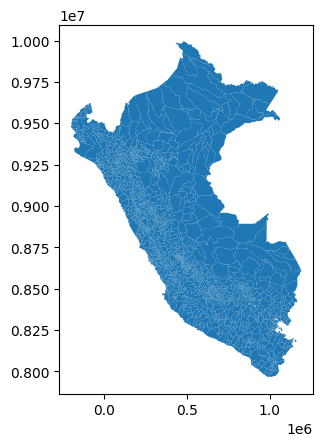

In [60]:
peru_distritos=peru_distritos.to_crs(32718)
peru_distritos.plot()

Besides the spatial units (DEPARTAMEN, PROVINCIA, DISTRITO, and Ubigeo - "Ubigeo" is a code ), you have:
 - **Poblacion**: Population (2017)
 - **Superficie**: Area               
 - **IDH2019**: Human Development Index for DISTRITO (2019)                   
 - **Educ_sec_comp2019_pct**: Share of Population that finished High-School (2019)     
 - **NBI2017_pct**: Share of Population with poverty at the household level aggregated by DISTRITO. This index ("Unsatisfied Basic Needs") uses observable living conditions rather than income alone (2017).
 - **Viv_sin_serv_hig2017_pct**: Share of housing units that have no sanitation infrastructure aggregated by  DISTRITO (2017)

The last two sections (III and IV) will need these **social data**.


Notice we should not use the 'distrito' name as index, because several of them are repeated:

In [61]:
peru_distritos[peru_distritos['DISTRITO'].duplicated()]

,DEPARTAMEN,PROVINCIA,DISTRITO,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
191,PUNO,LAMPA,PALCA,210706,2871,483.96,0.465326,68.506619,61.6,14.3,"MULTIPOLYGON (((980731.13 8315234.38, 980743.3..."
214,AYACUCHO,PAUCAR DEL SARA SARA,LAMPA,050804,2590,289.45,0.395363,60.608667,31.3,15.4,"MULTIPOLYGON (((666120.18 8335108.23, 666139.9..."
256,AYACUCHO,LUCANAS,SANTA LUCIA,050621,889,1019.14,0.442814,58.278405,64.7,47.6,"MULTIPOLYGON (((565436.58 8372074.78, 565495.3..."
259,AYACUCHO,LUCANAS,SAN CRISTOBAL,050615,2182,391.83,0.236161,68.230879,31.5,13.7,"MULTIPOLYGON (((576905.62 8374974.87, 577009.7..."
272,CUSCO,ESPINAR,COPORAQUE,080803,18004,1564.46,0.289550,75.551079,26.1,8.9,"MULTIPOLYGON (((863229.34 8390956.29, 863465.6..."
...,...,...,...,...,...,...,...,...,...,...,...
1844,LIMA,LIMA,LA VICTORIA,150115,169270,8.74,0.714159,74.791799,15.3,0.0,"MULTIPOLYGON (((280479.644 8666127.227, 280593..."
1845,LIMA,LIMA,SAN LUIS,150134,59377,3.49,0.793258,80.699041,9.4,0.0,"MULTIPOLYGON (((282530.051 8665926.351, 282499..."
1847,LIMA,LIMA,SAN MIGUEL,150136,139399,10.72,0.822401,76.664090,4.5,0.0,"MULTIPOLYGON (((273775.884 8664656.624, 273772..."
1855,LIMA,LIMA,SAN ISIDRO,150131,54298,11.10,0.788832,78.470219,1.1,0.0,"MULTIPOLYGON (((277019.308 8663207.821, 277130..."


Let's use 'Ubigeo', although it is not the best solution

In [62]:
# of course
peru_distritos[peru_distritos['Ubigeo'].duplicated()]

,DEPARTAMEN,PROVINCIA,DISTRITO,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry


In [63]:
#then
peru_distritos.set_index('Ubigeo', inplace=True)

**NOTICE** both projections used above are equal-area ones, which are standard for distance computations in meters.

## I. Who is my neighbor?

In spatial analysis, the intuitive concept of a “neighbor” can be operationalized in multiple ways.

So far, we have identified neighbors using geometric operations such as buffering, spatial joins, and overlays.

In this session, let’s remember the distance matrix:


In [64]:
sub_us.geometry.apply\
(lambda state: sub_us.distance(state)/1000)

NAME,New Mexico,Alabama,Georgia,Colorado,Utah,Florida,Arizona
NAME,,,,,,,
New Mexico,0.000000,1335.545817,1566.497206,0.000000,0.000000,1465.081515,0.000000
Alabama,1335.545817,0.000000,0.000000,1255.006182,1871.376284,0.000000,1871.318282
Georgia,1566.497206,0.000000,0.000000,1483.854043,2100.550282,0.000000,2100.987018
Colorado,0.000000,1255.006182,1483.854043,0.000000,0.000000,1482.065872,0.000000
Utah,0.000000,1871.376284,2100.550282,0.000000,0.000000,2072.233725,0.000000
Florida,1465.081515,0.000000,0.000000,1482.065872,2072.233725,0.000000,2024.875978
Arizona,0.000000,1871.318282,2100.987018,0.000000,0.000000,2024.875978,0.000000


You can see roughly the distances here:

(269573.5585624533, 2250700.3160064733)

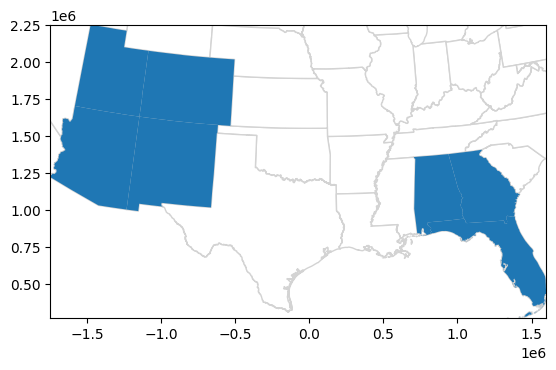

In [65]:
# Get the bounding box coordinates of sub_us
minx, miny, maxx, maxy = sub_us.total_bounds

base = us_states.plot(facecolor='white', edgecolor='lightgrey')
sub_us.plot(ax=base)
# Set the x and y limits of the plot to the bounding box
base.set_xlim(minx, maxx)
base.set_ylim(miny, maxy)

From this matrix and plot, you’ll notice that neighboring features have a distance of zero—this occurs when two polygons share a boundary (i.e., they are contiguous). This observation helps illustrate the different approaches to defining neighbors:

1. Binary Relationships:

* Contiguity: Two polygons are considered neighbors if they share any portion of their boundary—whether at a point, along a line segment, or more extensively. In the distance matrix, such pairs show a distance of zero, reflecting direct spatial adjacency.

    * Queen contiguity
    * Rook contiguity

* Proximity: This approches do not require contiguity.
    - Nearest Neighbors
    - Within influence zone

2. Continuous Relationships

* Contiguity: The relationship is graded by  the length of the shared boundary between contiguous neighbors.

* Proximity:
    - Nearest neighbors.
    - Within influence zone


Using matrices for this relationships—rather than raw geometries—is essential for the mathematical abstraction/representation and numerical computation required in upcoming spatial analytics techniques.

We will introduce some of PySAL (libpysal), which is designed to handle spatial relationship matrices and integrates seamlessly with GeoPandas. PySAL uses graph-based representations of these matrice, which  is not only more memory-efficient but also speeds up computation and simplifies visualization—especially for large or sparse spatial datasets.  A key concept in these graphs is the distinction between:

- Focal unit: the spatial feature (e.g., a state, county, or census tract) for which we are identifying neighbors.
- Neighbor(s): the other spatial units that are considered related to the focal unit based on a chosen criterion (e.g., contiguity, distance, or shared border length).

Let’s become familiar with the ```graph``` module in PySAL/libpysal, which provides a modern and flexible framework for constructing and working with spatial neighbor graphs.


In [66]:
from libpysal.graph import Graph

# also for reproducibility!
from numpy.random import seed
seed(42)

### I.1 Binary Contiguity

Take a look at the **queen** and **rook** relationship:

<center><img src="https://github.com/CienciaDeDatosEspacial/spatial_autoCorr/raw/main/rookQueen.png" width="700"></center>

From the image above:
- Your **rook** neighbor is whichever  shares a border with you (a borderline of at least two points). It is also known as the _Von Neumann_ neighbor.

- Your **queen** neighbor is whichever  shares a border or a corner with you (at least one point).It is also known as the _Moore_ neighbor.

Let's see how to get each set of neighbors

#### I.1.A. Rook

* The key idea: A focal polygon considers another polygon a neighbor if they share a common edge—that is, two or more connected points forming a line segment of positive length.
* The input: A GeoDataFrame (GDF) containing polygon geometries (e.g., states, counties, census tracts). Each row represents a spatial unit that can serve as a focal observation.
* The process: For each polygon (focal unit), the algorithm checks all other polygons to determine whether their boundaries intersect along a line segment (not just at a point).
* The output: A graph built from a binary adjacency matrix where each node represents a polygon (focal unit). An edge exists between two nodes only if they share a boundary segment. The corresponding adjacency matrix is binary. Isolates are possible.

Let's use **sub_us** GDF:

In [67]:
rook=Graph.build_contiguity(sub_us,rook=True) # rook by default

Now let's check the ouput:

**a. adjacency**

In [68]:
rook.adjacency

focal       neighbor  
New Mexico  Colorado      1
            Arizona       1
Alabama     Georgia       1
            Florida       1
Georgia     Alabama       1
            Florida       1
Colorado    New Mexico    1
            Utah          1
Utah        Colorado      1
            Arizona       1
Florida     Alabama       1
            Georgia       1
Arizona     New Mexico    1
            Utah          1
Name: weight, dtype: int64

The previous results shows only the neighbors of the focals, to recreate a wide format:

In [69]:
import pandas as pd
pd.DataFrame(rook.adjacency).unstack()

weight                                              
neighbor   New Mexico Alabama Georgia Colorado Utah Florida Arizona
focal                                                              
New Mexico        NaN     NaN     NaN      1.0  NaN     NaN     1.0
Alabama           NaN     NaN     1.0      NaN  NaN     1.0     NaN
Georgia           NaN     1.0     NaN      NaN  NaN     1.0     NaN
Colorado          1.0     NaN     NaN      NaN  1.0     NaN     NaN
Utah              NaN     NaN     NaN      1.0  NaN     NaN     1.0
Florida           NaN     1.0     1.0      NaN  NaN     NaN     NaN
Arizona           1.0     NaN     NaN      NaN  1.0     NaN     NaN

We generally fill those missing values (not a neighbor) with zero.

In [70]:
rook_Matrix=pd.DataFrame(rook.adjacency).unstack().fillna(0)
rook_Matrix

weight                                              
neighbor   New Mexico Alabama Georgia Colorado Utah Florida Arizona
focal                                                              
New Mexico        0.0     0.0     0.0      1.0  0.0     0.0     1.0
Alabama           0.0     0.0     1.0      0.0  0.0     1.0     0.0
Georgia           0.0     1.0     0.0      0.0  0.0     1.0     0.0
Colorado          1.0     0.0     0.0      0.0  1.0     0.0     0.0
Utah              0.0     0.0     0.0      1.0  0.0     0.0     1.0
Florida           0.0     1.0     1.0      0.0  0.0     0.0     0.0
Arizona           1.0     0.0     0.0      0.0  1.0     0.0     0.0

SInce we are going to use several times, we may create a custom procedure:

In [71]:
#instead of
# pd.DataFrame(rook.adjacency).unstack().fillna(0)
toWideMatrix=lambda g:pd.DataFrame(g.adjacency).unstack().fillna(0)

Notice we created this wide matrix for pedagogical purposes. It is a bad idea if you have many columns and rows.

**b. adjacency graph**

As we have a `GRAPH`, we can identify these neighborhood relationships via edges:

In [72]:
##this will be used several times:
general_arguments=dict(gdf=sub_us,node_kws=dict(color='red'), edge_kws=dict(alpha=0.4,color='blue'),zoom_start = 6)
rook.explore(**general_arguments)

#### I.1.B. Queen

* The key idea: A focal polygon considers another polygon a neighbor if they share a common edge or a vertex (at least one point).
* The input: A GeoDataFrame (GDF) containing polygon geometries (e.g., states, counties, census tracts). Each row represents a spatial unit that can serve as a focal observation.
* The process: For each polygon (focal unit), the algorithm checks all other polygons to determine whether their boundaries intersect at any point or along a line segment.
* The output: A graph built from a binary adjacency matrix where each node represents a polygon (focal unit). An edge exists between two nodes only if they share a point or boundary segment. The corresponding adjacency matrix is binary. Isolates are possible.

Let's see what we get:

**a. adjacency matrix**

In [73]:
queen=Graph.build_contiguity(sub_us,rook=False)

# applying our procedure:

queen_Matrix=toWideMatrix(queen)
queen_Matrix

weight                                              
neighbor   New Mexico Alabama Georgia Colorado Utah Florida Arizona
focal                                                              
New Mexico        0.0     0.0     0.0      1.0  1.0     0.0     1.0
Alabama           0.0     0.0     1.0      0.0  0.0     1.0     0.0
Georgia           0.0     1.0     0.0      0.0  0.0     1.0     0.0
Colorado          1.0     0.0     0.0      0.0  1.0     0.0     1.0
Utah              1.0     0.0     0.0      1.0  0.0     0.0     1.0
Florida           0.0     1.0     1.0      0.0  0.0     0.0     0.0
Arizona           1.0     0.0     0.0      1.0  1.0     0.0     0.0

**b. adjacency plot**

In [74]:
queen.explore(**general_arguments)


### I.2 Binary Proximity


#### I.2.A. Nearest Neighbors

* The key idea: A focal polygon considers another polygon a neighbor if that second polygon is among the K closest polygons to the focal polygon, where “closeness” is measured by the distance between their geometric centroids (or any other user-supplied distance metric).  
* The input: A GeoDataFrame (GDF) containing polygon geometries. Each row represents a spatial unit that can serve as a focal observation.  
* The process: For each polygon (focal unit), the algorithm (1) computes the distance between its centroid and every other centroid, (2) ranks these distances, and (3) flags the K smallest distances as neighbors. Ties can be broken by random selection, ID order, or by including all tied candidates.  
* The output: A graph built from a binary adjacency matrix where each node represents a polygon (focal unit). An edge exists between two nodes whenever one polygon is among the K nearest neighbors of the other. The corresponding adjacency matrix is binary and, by construction, typically asymmetric unless a symmetric constraint is explicitly enforced. No isolates in output.

If assume K is 3:

**a. adjacency matrix**

In [75]:
knn3 = Graph.build_knn(sub_us.representative_point(), # GDF
                                 k=3) # desired k

knn3_Matrix=toWideMatrix(knn3)
knn3_Matrix

weight                                              
neighbor   New Mexico Alabama Georgia Colorado Utah Florida Arizona
focal                                                              
New Mexico        0.0     0.0     0.0      1.0  1.0     0.0     1.0
Alabama           1.0     0.0     1.0      0.0  0.0     1.0     0.0
Georgia           1.0     1.0     0.0      0.0  0.0     1.0     0.0
Colorado          1.0     0.0     0.0      0.0  1.0     0.0     1.0
Utah              1.0     0.0     0.0      1.0  0.0     0.0     1.0
Florida           1.0     1.0     1.0      0.0  0.0     0.0     0.0
Arizona           1.0     0.0     0.0      1.0  1.0     0.0     0.0

**b. adjacency plot**

In [76]:
knn3.explore(**general_arguments)

#### I.2.B Within zone of influence


* The key idea: A focal polygon considers another polygon a neighbor if the distance between them (usually centroid-to-centroid , or a pair of representative point) lies within a user-defined band.
* The input: A GeoDataFrame (GDF) containing polygon geometries for which a representative point is supplied. Each row represents a spatial unit that can serve as a focal observation, plus (optionally) an attribute column to use as a weight or ID.  
* The process: For each polygon (focal unit) the algorithm computes the distance to every other polygon and flags those whose distance falls inside the specified band.
* The output: A binary spatial graph (or adjacency structure) where each node represents a polygon. An edge exists between two nodes only if their mutual distance sits inside the chosen band. The corresponding adjacency matrix is binary and symmetric by construction. Isolates are possible.

Let's assume a 750 km distance band:

In [77]:
band750k_Bi=Graph.build_distance_band(sub_us.representative_point(), threshold=750000)

band750k_Bi_Matrix=toWideMatrix(band750k_Bi)
band750k_Bi_Matrix

weight                                              
neighbor   New Mexico Alabama Georgia Colorado Utah Florida Arizona
focal                                                              
New Mexico        0.0     0.0     0.0      1.0  1.0     0.0     1.0
Alabama           0.0     0.0     1.0      0.0  0.0     1.0     0.0
Georgia           0.0     1.0     0.0      0.0  0.0     1.0     0.0
Colorado          1.0     0.0     0.0      0.0  1.0     0.0     0.0
Utah              1.0     0.0     0.0      1.0  0.0     0.0     1.0
Florida           0.0     1.0     1.0      0.0  0.0     0.0     0.0
Arizona           1.0     0.0     0.0      0.0  1.0     0.0     0.0

In [78]:
band750k_Bi.explore(**general_arguments)

### I.3 Continuos Proximity

#### I.3.A. Within zone of influence

* The key idea: A focal polygon considers another polygon a neighbor if the distance between them (usually centroid-to-centroid , or a pair of representative point) lies within a user-defined band.
* The input: A GeoDataFrame (GDF) containing polygon geometries for which a representative point is supplied. Each row represents a spatial unit that can serve as a focal observation, plus (optionally) an attribute column to use as a weight or ID.  
* The process: For each polygon (focal unit) the algorithm computes the distance to every other polygon and flags those whose distance falls inside the specified band.
* **The output**: a graph where each node has edges to all nodes ('neighbors') whose representative points lie within the radius. Edges are represented by a continuous adjacency matrix, the default values represent the inverse distance between the nodes in the edges. Isolates are possible

Here it is:

In [79]:
band2Mk_C=Graph.build_distance_band(sub_us.representative_point(), threshold=2000000,binary=False)

band2Mk_C_Matrix=toWideMatrix(band2Mk_C)
band2Mk_C_Matrix


/usr/local/lib/python3.12/dist-packages/libpysal/graph/base.py:839: RuntimeWarning: divide by zero encountered in power
  kernel=lambda distances, alpha: np.power(distances, alpha),


weight                                                  \
neighbor      New Mexico       Alabama   Georgia      Colorado      Utah   
focal                                                                      
New Mexico  0.000000e+00  5.566969e-07  0.000000  1.931756e-06  0.000001   
Alabama     5.566969e-07  0.000000e+00  0.000003  5.452476e-07  0.000000   
Georgia     0.000000e+00  3.091882e-06  0.000000  0.000000e+00  0.000000   
Colorado    1.931756e-06  5.452476e-07  0.000000  0.000000e+00  0.000002   
Utah        1.339370e-06  0.000000e+00  0.000000  1.941729e-06  0.000000   
Florida     0.000000e+00  1.401714e-06  0.000002  0.000000e+00  0.000000   
Arizona     1.906394e-06  0.000000e+00  0.000000  1.290438e-06  0.000002   

                                
neighbor     Florida   Arizona  
focal                           
New Mexico  0.000000  0.000002  
Alabama     0.000001  0.000000  
Georgia     0.000002  0.000000  
Colorado    0.000000  0.000001  
Utah        0.000000  0.000002  
Florida     0.000000  0.000000  
Arizona     0.000000  0.000000

The plot:

In [80]:
band2Mk_C.explore(**general_arguments)

Above, you do not see the continuous information present in the edges, for that, you may plot one of the states using **focal=**:

In [81]:
# pay attention to one state:
focal_args=dict(gdf=sub_us,focal='Arizona',edge_kws=dict(column="weight",style_kwds=dict(weight=6)),zoom_start=6)
band2Mk_C.explore(**focal_args)


#### I.3.B. Kernel K-Nearest Neighbors (KNN)

* The key idea: Each polygon keeps only other  K closest polygons, but instead of a blunt 0 / 1 the tie is a gentle “friendliness” score that shrinks with distance.  
* The input: A GeoDataFrame of polygons + their representative points.  
* The process:  
  – Find the K nearest points.  
  – Turn distance into a Gaussian bell value (big when close, small when far).  

* The output: A weighted graph where every node has exactly K neighbours carrying continuous “soft” weights; no isolates, no huge clumps, just K tidy friendship levels per row.

Let's use K = 3 again:

In [82]:
kernel3 = Graph.build_kernel(sub_us.representative_point(), k=3)

kernel3_Matrix=toWideMatrix(kernel3)
kernel3_Matrix

weight                                                    \
neighbor   New Mexico   Alabama   Georgia  Colorado      Utah   Florida   
focal                                                                     
New Mexico   0.000000  0.000000  0.000000  0.389967  0.380498  0.000000   
Alabama      0.303328  0.000000  0.395414  0.000000  0.000000  0.382068   
Georgia      0.273487  0.395414  0.000000  0.000000  0.000000  0.388504   
Colorado     0.389967  0.000000  0.000000  0.000000  0.390058  0.000000   
Utah         0.380498  0.000000  0.000000  0.390058  0.000000  0.000000   
Florida      0.241971  0.382068  0.388504  0.000000  0.000000  0.000000   
Arizona      0.389729  0.000000  0.000000  0.379109  0.387067  0.000000   

                      
neighbor     Arizona  
focal                 
New Mexico  0.389729  
Alabama     0.000000  
Georgia     0.000000  
Colorado    0.379109  
Utah        0.387067  
Florida     0.000000  
Arizona     0.000000

Notice we have bigger values that the continuous band-based result. Let's see the basic plot:

In [83]:

kernel3.explore(**general_arguments)

Focusing on one state:

In [84]:

kernel3.explore(**focal_args)

### I.4 Continuous Contiguity


* **The key idea**: A focal polygon treats another polygon as a neighbour only if the two share a common border.  
* **The input**: A GeoDataFrame of polygons; no extra points needed.  
* **The process**:  
  – Compute the exact length of every shared boundary segment.  

  
* **The output**: A weighted graph encoded in a sparse weights matrix; each non-zero entry is the **metres (or map-units) of shared border**, giving large, jagged polygons more influence over their neighbours than small, compact ones. Isolates are possible.

In [85]:
perimeter = Graph.build_contiguity(sub_us, by_perimeter=True) #rook by default

perimeter_Matrix=toWideMatrix(perimeter)
perimeter_Matrix


weight                                               \
neighbor       New Mexico        Alabama        Georgia       Colorado   
focal                                                                    
New Mexico       0.000000       0.000000       0.000000  533279.672343   
Alabama          0.000000       0.000000  516031.088646       0.000000   
Georgia          0.000000  516031.088646       0.000000       0.000000   
Colorado    533279.672343       0.000000       0.000000       0.000000   
Utah             0.000000       0.000000       0.000000  448548.967006   
Florida          0.000000  368082.376500  480039.092644       0.000000   
Arizona     633212.948554       0.000000       0.000000       0.000000   

                                                         
neighbor             Utah        Florida        Arizona  
focal                                                    
New Mexico       0.000000       0.000000  633212.948554  
Alabama          0.000000  368082.376500       0.000000  
Georgia          0.000000  480039.092644       0.000000  
Colorado    448548.967006       0.000000       0.000000  
Utah             0.000000       0.000000  441465.946404  
Florida          0.000000       0.000000       0.000000  
Arizona     441465.946404       0.000000       0.000000

The basic plot:

In [86]:

perimeter.explore(**general_arguments)

Focusing on one state:

In [87]:

perimeter.explore(**focal_args)

In summary:

| Technique | Pros | Cons | Typical use-case example |
|-----------|------|------|--------------------------|
| **Rook / Queen contiguity** | Simple, law- or admin-based, no distance parameter | Islands get 0 neighbours; ignores “near but not touching” units | State-to-state policy diffusion, local tax spill-overs |
| **K-NN (binary)** | Guarantees every unit has same #neighbours; no islands | Can link far-away units in sparse areas; ignores true borders | Comparative politics with same-size legislatures, small-N samples |
| **Distance band (binary)** | Hard cap on geographic reach; easy to interpret radius | Sparse → islands; dense → huge cliques; radius must be tuned | Housing-price spill-overs within 30 km commuting range |
| **Continuous distance-band** | Smooth weights, still respects max range | Same radius-tuning and island issues as binary band | Environmental exposure declining with distance, gravity models |
| **Kernel K-NN** | Fixed neighbour count, adaptive bandwidth, no islands | Far neighbours possible in deserts/oceans; parameter k to pick | Identifying neighbors that contribute to a smoothly decaying environmental hazard level.|
| **Perimeter-weighted contiguity** | Uses real boundary, good for irregular shapes | Needs clean topology; computation heavier | Ecological edge effects, river-basin pollution, crop pest spread |

## II. Neighborhoods as weights

Our matrices tell us which are neighbors, and some give us additional information related to the 'farness' of the identified neighbor. Let me compute the marginal values by row (sum):

In [88]:
allMx=[rook_Matrix.sum(axis=1),
       queen_Matrix.sum(axis=1),
       knn3_Matrix.sum(axis=1),
       band750k_Bi_Matrix.sum(axis=1),
       band2Mk_C_Matrix.sum(axis=1),
       kernel3_Matrix.sum(axis=1),
       perimeter_Matrix.sum(axis=1)]
pd.concat(allMx,axis=1)

,0,1,2,3,4,5,6
focal,,,,,,,
New Mexico,2.0,3.0,3.0,3.0,0.000006,1.160194,1.166493e+06
Alabama,2.0,2.0,3.0,2.0,0.000006,1.080810,8.841135e+05
Georgia,2.0,2.0,3.0,2.0,0.000005,1.057405,9.960702e+05
Colorado,2.0,3.0,3.0,2.0,0.000006,1.159133,9.818286e+05
Utah,2.0,3.0,3.0,3.0,0.000005,1.157623,8.900149e+05
Florida,2.0,2.0,3.0,2.0,0.000003,1.012543,8.481215e+05
Arizona,2.0,3.0,3.0,2.0,0.000005,1.155905,1.074679e+06


We know that no-neighbors have value zero in the matrix. Then, non-zero (binary or non-binary) values carries some weight .
However, they are currently not normalized (they do not add to 1 by row), which may bias further procedures as raw values may 'distort' mathematical modelling.

For example, this binary matrix is non-normalized:

In [89]:
queen_Matrix

weight                                              
neighbor   New Mexico Alabama Georgia Colorado Utah Florida Arizona
focal                                                              
New Mexico        0.0     0.0     0.0      1.0  1.0     0.0     1.0
Alabama           0.0     0.0     1.0      0.0  0.0     1.0     0.0
Georgia           0.0     1.0     0.0      0.0  0.0     1.0     0.0
Colorado          1.0     0.0     0.0      0.0  1.0     0.0     1.0
Utah              1.0     0.0     0.0      1.0  0.0     0.0     1.0
Florida           0.0     1.0     1.0      0.0  0.0     0.0     0.0
Arizona           1.0     0.0     0.0      1.0  1.0     0.0     0.0

But this binary matrix is normalized (by **r**ows):

In [90]:
toWideMatrix(queen.transform("r"))

weight                                                      
neighbor   New Mexico Alabama Georgia  Colorado      Utah Florida   Arizona
focal                                                                      
New Mexico   0.000000     0.0     0.0  0.333333  0.333333     0.0  0.333333
Alabama      0.000000     0.0     0.5  0.000000  0.000000     0.5  0.000000
Georgia      0.000000     0.5     0.0  0.000000  0.000000     0.5  0.000000
Colorado     0.333333     0.0     0.0  0.000000  0.333333     0.0  0.333333
Utah         0.333333     0.0     0.0  0.333333  0.000000     0.0  0.333333
Florida      0.000000     0.5     0.5  0.000000  0.000000     0.0  0.000000
Arizona      0.333333     0.0     0.0  0.333333  0.333333     0.0  0.000000

Another example, this binary matrix is non-normalized

In [91]:
perimeter_Matrix

weight                                               \
neighbor       New Mexico        Alabama        Georgia       Colorado   
focal                                                                    
New Mexico       0.000000       0.000000       0.000000  533279.672343   
Alabama          0.000000       0.000000  516031.088646       0.000000   
Georgia          0.000000  516031.088646       0.000000       0.000000   
Colorado    533279.672343       0.000000       0.000000       0.000000   
Utah             0.000000       0.000000       0.000000  448548.967006   
Florida          0.000000  368082.376500  480039.092644       0.000000   
Arizona     633212.948554       0.000000       0.000000       0.000000   

                                                         
neighbor             Utah        Florida        Arizona  
focal                                                    
New Mexico       0.000000       0.000000  633212.948554  
Alabama          0.000000  368082.376500       0.000000  
Georgia          0.000000  480039.092644       0.000000  
Colorado    448548.967006       0.000000       0.000000  
Utah             0.000000       0.000000  441465.946404  
Florida          0.000000       0.000000       0.000000  
Arizona     441465.946404       0.000000       0.000000

We know:

In [92]:
pd.concat([perimeter_Matrix,perimeter_Matrix.sum(axis=1).rename("SUM")],axis=1)

,"(weight, New Mexico)","(weight, Alabama)","(weight, Georgia)","(weight, Colorado)","(weight, Utah)","(weight, Florida)","(weight, Arizona)",SUM
focal,,,,,,,,
New Mexico,0.000000,0.000000,0.000000,533279.672343,0.000000,0.000000,633212.948554,1.166493e+06
Alabama,0.000000,0.000000,516031.088646,0.000000,0.000000,368082.376500,0.000000,8.841135e+05
Georgia,0.000000,516031.088646,0.000000,0.000000,0.000000,480039.092644,0.000000,9.960702e+05
Colorado,533279.672343,0.000000,0.000000,0.000000,448548.967006,0.000000,0.000000,9.818286e+05
Utah,0.000000,0.000000,0.000000,448548.967006,0.000000,0.000000,441465.946404,8.900149e+05
Florida,0.000000,368082.376500,480039.092644,0.000000,0.000000,0.000000,0.000000,8.481215e+05
Arizona,633212.948554,0.000000,0.000000,0.000000,441465.946404,0.000000,0.000000,1.074679e+06


Here it is normalized:

In [93]:
toWideMatrix(perimeter.transform("r"))

weight                                                    \
neighbor   New Mexico   Alabama   Georgia  Colorado      Utah   Florida   
focal                                                                     
New Mexico   0.000000  0.000000  0.000000  0.457165  0.000000  0.000000   
Alabama      0.000000  0.000000  0.583671  0.000000  0.000000  0.416329   
Georgia      0.000000  0.518067  0.000000  0.000000  0.000000  0.481933   
Colorado     0.543149  0.000000  0.000000  0.000000  0.456851  0.000000   
Utah         0.000000  0.000000  0.000000  0.503979  0.000000  0.000000   
Florida      0.000000  0.433997  0.566003  0.000000  0.000000  0.000000   
Arizona      0.589211  0.000000  0.000000  0.000000  0.410789  0.000000   

                      
neighbor     Arizona  
focal                 
New Mexico  0.542835  
Alabama     0.000000  
Georgia     0.000000  
Colorado    0.000000  
Utah        0.496021  
Florida     0.000000  
Arizona     0.000000

Let's confirm:

In [94]:
Mtrans = toWideMatrix(perimeter.transform("r"))

# CORRECTED CODE
pd.concat([Mtrans, Mtrans.sum(axis=1).rename("SUM")], axis=1)

,"(weight, New Mexico)","(weight, Alabama)","(weight, Georgia)","(weight, Colorado)","(weight, Utah)","(weight, Florida)","(weight, Arizona)",SUM
focal,,,,,,,,
New Mexico,0.000000,0.000000,0.000000,0.457165,0.000000,0.000000,0.542835,1.0
Alabama,0.000000,0.000000,0.583671,0.000000,0.000000,0.416329,0.000000,1.0
Georgia,0.000000,0.518067,0.000000,0.000000,0.000000,0.481933,0.000000,1.0
Colorado,0.543149,0.000000,0.000000,0.000000,0.456851,0.000000,0.000000,1.0
Utah,0.000000,0.000000,0.000000,0.503979,0.000000,0.000000,0.496021,1.0
Florida,0.000000,0.433997,0.566003,0.000000,0.000000,0.000000,0.000000,1.0
Arizona,0.589211,0.000000,0.000000,0.000000,0.410789,0.000000,0.000000,1.0


These new row-standardized matrices will serve a greater purpose: the computing of **spatial lags**.

## III. How are my neighbors doing...?

The actual question should be related to a social variable, for example, poverty, mortality, education, etc.

For example, this is "how each distrito is doing" related to HS education (share of population that completed high school):

In [95]:
peru_distritos.Educ_sec_comp2019_pct.describe()

,Educ_sec_comp2019_pct
count,1874.000000
mean,55.769523
std,15.728123
min,11.974433
25%,44.466678
50%,57.164771
75%,68.202230
max,91.744878


See the choropleth (quantile bining):

<Axes: >

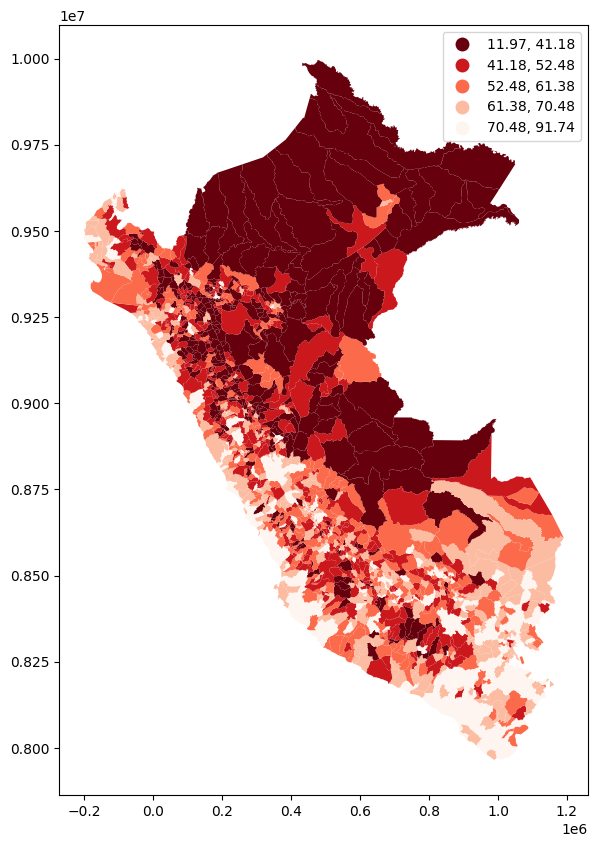

In [96]:
peru_distritos.plot(
    "Educ_sec_comp2019_pct",
    scheme="quantiles",
    cmap="Reds_r",
    legend=True,figsize=(12, 10))

In [97]:
import geopandas as gpd
peru_good=gpd.read_file(peruDataLink,layer='good_geom')

The title was asking about the situation of neighbors (the **neighbors** of each **focal** in my data). In this case, each focal has an education indicator (value), then, the average of the neighbors of each focal is a new value (new column) which we call **spatial lag** of that variable.

We do not have yet Peru's  neigborhood graph for the adjacency matrix. Let's try to get it:

In [98]:
peru_perim = Graph.build_contiguity(peru_distritos, rook=False)

We are in trouble, the map quality is not good. This will always be a key consideration.

I have another map with data, based on an official [website](https://www.geoidep.gob.pe/servicios-idep/servicios-de-publicacion-de-objetos-wfs).

In [99]:
peru_good=gpd.read_file(peruDataLink,layer='good_geom')

Let's retry:

In [100]:
peru_perim=Graph.build_contiguity(peru_good,by_perimeter=True)

This time it worked!

Now, let's get the normalized matrix:

In [101]:
peru_perim=peru_perim.transform("r")

Then,  the spatial lag of the variable "Educ_sec_comp2019_pct" can be obtained like this:

In [102]:
ylag = peru_perim.lag(peru_good["Educ_sec_comp2019_pct"])

Let me add it to the GDF:

In [103]:
peru_good=peru_good.assign(Educ_sec_comp2019_pct_lagged=ylag)
peru_good.head()

,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry,Educ_sec_comp2019_pct_lagged
0,Apurimac,ABANCAY,ABANCAY,PE030101,56871,0.600375,78.865450,15.8,2.9,"MULTIPOLYGON (((-72.93158 -13.55616, -72.9314 ...",61.701258
1,Ancash,BOLOGNESI,ABELARDO PARDO LEZAMETA,PE020502,1263,0.434687,50.434603,33.6,25.4,"MULTIPOLYGON (((-77.1474 -10.29675, -77.14643 ...",68.594709
2,Arequipa,CARAVELI,ACARI,PE040302,3010,0.634185,56.273614,26.2,8.8,"MULTIPOLYGON (((-74.61542 -15.13728, -74.61174...",55.033200
3,Ancash,OCROS,ACAS,PE021402,1057,0.469140,72.527156,70.4,67.6,"MULTIPOLYGON (((-77.26312 -10.43537, -77.26356...",56.212327
4,Cusco,PARURO,ACCHA,PE081002,3839,0.300626,64.586647,28.6,11.1,"MULTIPOLYGON (((-71.80912 -13.92427, -71.80901...",47.770424


Let's plot HS share against its lag:

<Axes: xlabel='Educ_sec_comp2019_pct', ylabel='Educ_sec_comp2019_pct_lagged'>

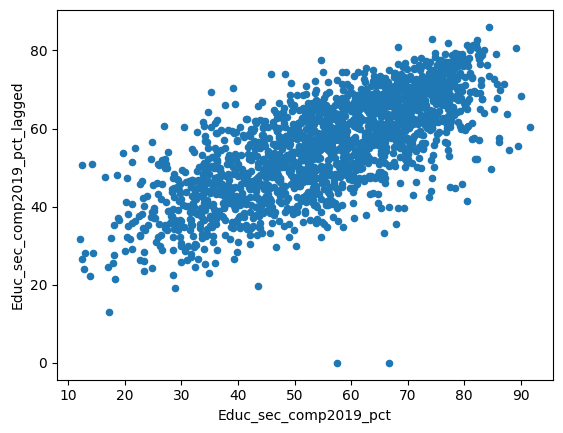

In [104]:
peru_good.plot.scatter("Educ_sec_comp2019_pct","Educ_sec_comp2019_pct_lagged")

## IV. Spatial autocorrelation

### IV. 1 Global

A correlation plot as the previous one should let us know if a variable is correlated with values of the neighbors (the lag), and if that were the case,  proximity is interfering statistical analysis, as the variable values are not independent.

The most well known measure to confirm that is the Moran's I index of global spatial correlation. Let's see the value we get:


In [105]:
import esda # from pysal

MoranGlobal_HS = esda.Moran(peru_good['Educ_sec_comp2019_pct'], peru_perim)

Once computed, you can retrieve its value and significance:

In [106]:
MoranGlobal_HS.I,MoranGlobal_HS.p_sim

(np.float64(0.5790496394122845), np.float64(0.001))

Moran’s I is interpreted like a Pearson r, but benchmarks are lower:

- |I| > 0.5 → strong, 0.2–0.5 → moderate, < 0.2 → weak.
- Sign indicates positive vs. negative spatial clustering.

Significance is assessed with a pseudo p-value from conditional randomisations of the data, because the theoretical null distribution is unknown for irregular spatial weights.

### IV. 2 Local

We can compute a Local Index of Spatial Association (LISA -local Moran) for each map polygon. That will help us find spatial clusters (spots) and spatial outliers:

- High-High (HH): values above average surrounded by values above average.These are also known as **hotSpot**s.
- Low-Low (LL): values below average surrounded by values below average. These are also known as **coldSpot**s.
- High-Low (HL): values above average surrounded by values below average.These are also known as **hotOutlier**s.
- Low-High (LH): values below average surrounded by values above average. These are also known as **coldOutlier**s.

It is also possible that no significant correlation is detected. Let's see those values:



a. Compute the LISAs:

In [107]:
lisa = esda.Moran_Local(peru_good['Educ_sec_comp2019_pct'], peru_perim)


/usr/local/lib/python3.12/dist-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


The previous warning may be due to the presence of isolates, produced by perimeter algorithm:

In [108]:
peru_perim.isolates

Index([51, 58], dtype='int64', name='focal')

These "islands" may create trouble. Should you keep using a _contiguity_ approach, you may consider fltering those out and recompute ``graph`` and ``lisa``:

In [109]:
islandCodes = peru_perim.isolates

peru_clean=peru_good.drop(index=islandCodes).copy()

peru_perim_clean=Graph.build_contiguity(peru_clean,by_perimeter=True).transform("r")
#
lisa = esda.Moran_Local(peru_clean['Educ_sec_comp2019_pct'], peru_perim_clean)



b. Plot the results (**fast way**)

<Axes: >

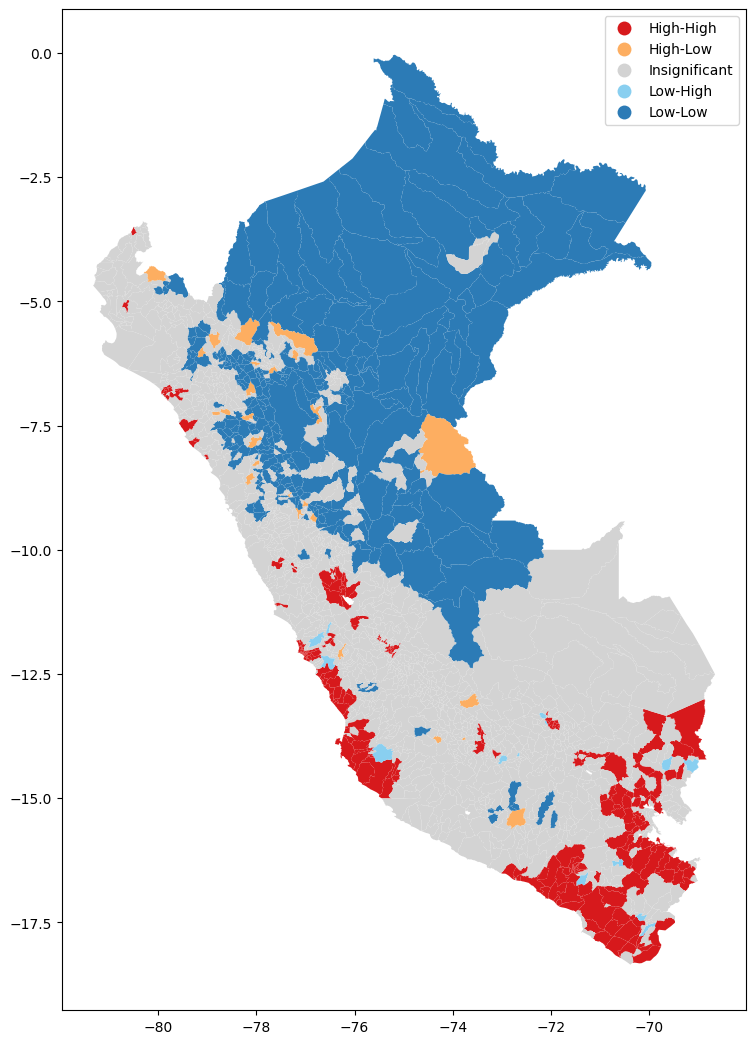

In [110]:
lisa.plot(peru_clean,crit_value=0.05,figsize=(10,13),legend=True)

#### IV. 2. 1 Analysis Local Spatial Correlation quadrants

You can not get the quadrant labels from the previous plot directly into the original GDF, thus complicating further analysis and exporting of those results.

First let's recover the labels into a new column:

In [111]:
# get the quadrants
peru_clean['HS_lisa'] = lisa.get_cluster_labels(crit_value=0.05)

In [112]:
# see the count
peru_clean['HS_lisa'].value_counts()

,count
HS_lisa,
Insignificant,1275
Low-Low,293
High-High,263
High-Low,26
Low-High,14


Now, we can prepare a comparisson:

In [113]:
TheStats=["mean", "min", "max","var"]


# stats by the lisa cluster
grouped_stats = peru_clean.groupby('HS_lisa')['Educ_sec_comp2019_pct'].agg(TheStats)

# stats for the entire, ungrouped column
global_stats = peru_clean['Educ_sec_comp2019_pct'].agg(TheStats)

# Convert 'global_stats' (Series) to a DataFrame with an appropriate index name
global_stats_df = pd.DataFrame(global_stats).T
global_stats_df.index = ['Global/Total'] # simple but key

# Combine both
pd.concat([grouped_stats, global_stats_df])



,mean,min,max,var
High-High,73.485907,55.840908,89.215043,44.571648
High-Low,60.894856,55.760611,69.435145,19.531914
Insignificant,56.556159,12.358409,91.744878,175.984069
Low-High,51.260047,39.073602,55.633847,21.016735
Low-Low,36.146981,11.974433,55.659182,100.766223
Global/Total,55.760485,11.974433,91.744878,247.694680


From the results above, you may have several concerns and keep asking more questions:

- High-High clusters are concentrated areas of high percent of graduation from HighSchool. Is that expected in those areas? What has caused that? Has this been the same for a long time?

- Low-Low clusters are concentrated areas of low percent of graduation from HighSchool. What would it take to make a change in these areas? No doubt some kind of intervention is needed.

- High-Low clusters detect districts that outperform their neighbors. Can we leverage on those to improve the area? Are they in danger of worsening?

- Low-High clusters detect districts that are much worse than their neighbors, who are actually doing pretty well. Can we improve this place considering the surroundings need less intervention or not at all?

#### IV. 2. 2 Customizing Local Spatial Correlation quadrants

At this stage, we can rename the previous column to customize cluster labels and colors:

In [114]:
##knowing
peru_clean['HS_lisa'].unique()

array(['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High'],
      dtype=object)

Keep in mind that the outliers may deserve more attention, so they may be at the top or bottom of the levels. You can add a number to achieve this purpose:

In [115]:
oldLabels=['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High']

# 3 will be at the middle
newLabels = ['3 no_pattern', '4 coldSpot','2 hotSpot','1 hotOutlier' , '5 coldOutlier']

labels = dict(zip(oldLabels, newLabels))

labels

{'Insignificant': '3 no_pattern',
 'Low-Low': '4 coldSpot',
 'High-High': '2 hotSpot',
 'High-Low': '1 hotOutlier',
 'Low-High': '5 coldOutlier'}

Just using this dictionary to rename the column:

In [116]:

peru_clean.replace({'HS_lisa':labels},inplace=True)

## see the count
peru_clean['HS_lisa'].value_counts().sort_index()

,count
HS_lisa,
1 hotOutlier,26
2 hotSpot,263
3 no_pattern,1275
4 coldSpot,293
5 coldOutlier,14


Finally, used that order to assign diverging color-blind safe palette:

<Axes: >

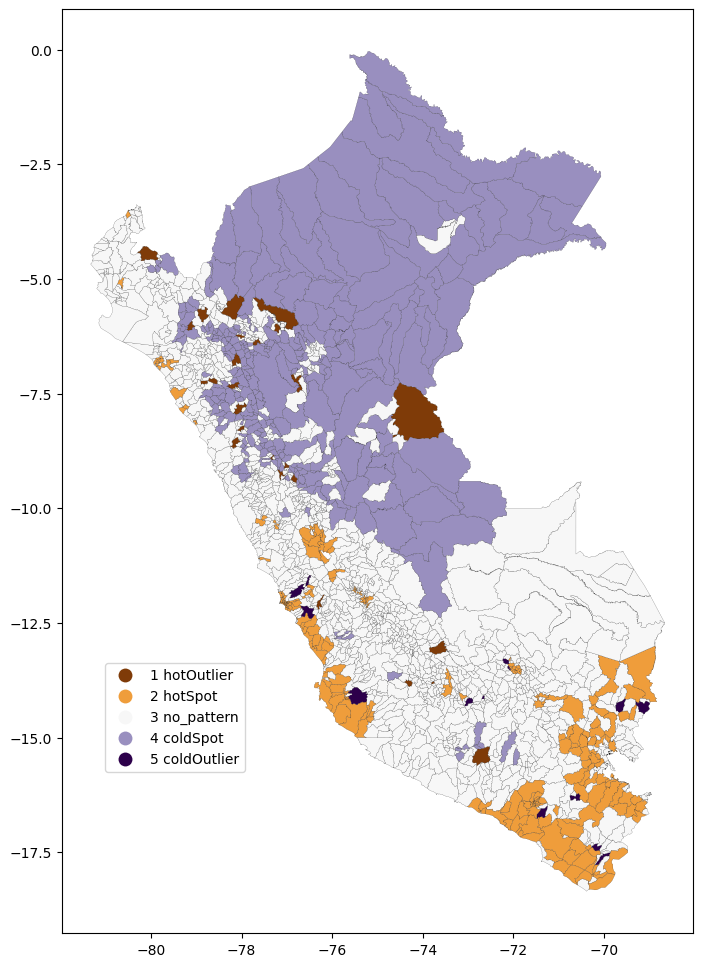

In [117]:
##custom colors- respect the previous order

import matplotlib.pyplot as plt
myColMap = plt.get_cmap('PuOr', 5)


##plot the map

peru_clean.plot(column='HS_lisa',
                categorical=True,
                cmap=myColMap,
                linewidth=0.1,
                edgecolor='k',
                legend=True,
                legend_kwds={'bbox_to_anchor': (0.3, 0.3)},
                figsize=(12,12))